# Classificacao de Cancer com Arvores de Decisao

Vamos classificar tumores em benignos ou malignos, baseado-se em diversos atributos destes.

## Imports, Carga de Dados, etc

#### Imports

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

#### Carga dos dados

In [2]:
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

## Validacao Cruzada

### QUESTAO 01

Analisar a eficacia do classificador DecisionTreeClassifier com diferentes valores do parametro `max_depth` (profundidade maxima da arvore).

Plote um grafico de linha mostrando a acuracia para diferentes valores deste parametro.

A acuracia deve ser a media (mean) dos valores obtidos em uma validacao cruzada.

Execute a validacao cruzada atraves da funcao: `cross_val_score`, especificando `scoring='accuracy'` e um valor inteiro para `cv` (quantidade de folds). Exemplo: `cv=10`

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=0,shuffle=True,stratify=y)

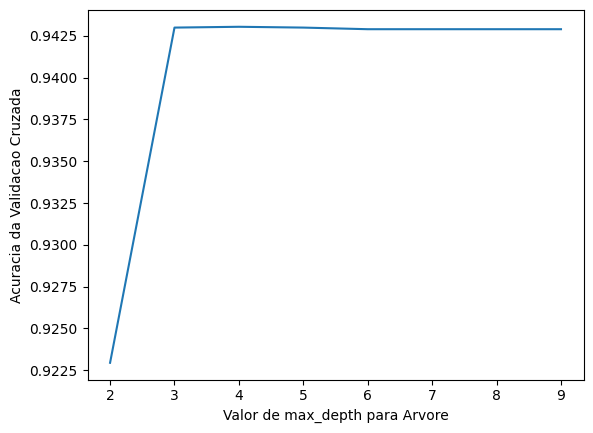

In [7]:
%matplotlib inline

# d variando de 2 a 9
d_range = range(2, 10)
mean_scores = []

for d in d_range:
    clf = DecisionTreeClassifier(max_depth=d,random_state=42)
    cv_values = cross_val_score(clf,X_train,y_train,scoring='accuracy',cv=10)
    mean_scores.append(np.mean(cv_values))

plt.plot(d_range, mean_scores)
plt.xlabel('Valor de max_depth para Arvore')
plt.ylabel('Acuracia da Validacao Cruzada')
plt.show()

### QUESTAO 02

Repita o experimento da questao anterior, porem, ao inves de especificar um valor inteiro para `cv`, especifique um separador personalizado.

O que vai mudar no codigo:

Antes do laco, instancie um objeto `StratifiedKFold` (equivalente ao KFold, porem, mantem um equilibrio na distribuicao das classes). Voce deve escolher os parametros.

`custom_cv = StratifiedKFold(....)`

O parametro `_cv_` do metodo `cross_val_score` deve ser especificado da seguinte maneira:

cross_val_score(..., cv=custom_cv, ...)

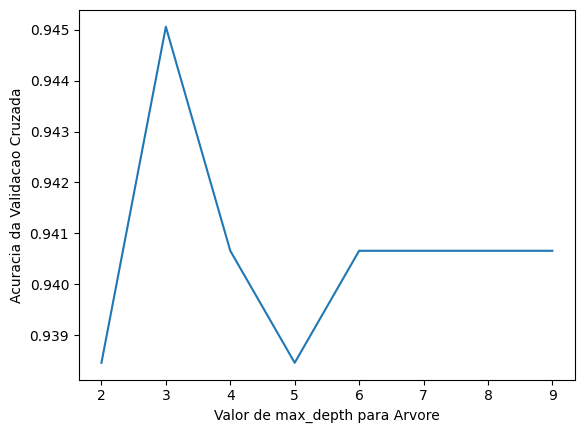

In [8]:
%matplotlib inline

# d variando de 2 a 9
d_range = range(2, 10)
mean_scores = []
custom_cv = StratifiedKFold()

for d in d_range:
    clf = DecisionTreeClassifier(max_depth=d,random_state=42)
    cv_values = cross_val_score(clf,X_train,y_train,scoring='accuracy',cv=custom_cv)
    mean_scores.append(np.mean(cv_values))

plt.plot(d_range, mean_scores)
plt.xlabel('Valor de max_depth para Arvore')
plt.ylabel('Acuracia da Validacao Cruzada')
plt.show()

### QUESTAO 03

Reflita sobre as escolhas que voce faria com base nos resultados destes experimentos para discutirmos na aula.